# Credit Card Approval & Limit 

**Problem:** Build two models for a bank —
1. **Approval Model** — predict if applicant should be approved
2. **Limit Model** — predict credit limit for approved applicants

**Goal:** Increase approval rate above 38% while keeping default rate below 4%


Upload and Load Dataset



In [6]:

uploaded = pd.read_csv(r"C:\Users\Abhishek_Yadav\Downloads\capstone2_creditline_dataset.csv")

Import Libraries

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error, r2_score

Helper Functions

Small functions used later in the project.

In [8]:
# Function to calculate Gini score
def get_gini(y_actual, y_predicted):
    auc = roc_auc_score(y_actual, y_predicted)
    return 2 * auc - 1

# Function to calculate KS statistic
def get_ks(y_actual, y_predicted):
    fpr, tpr, _ = roc_curve(y_actual, y_predicted)
    return max(tpr - fpr)

# Function to create bureau score bands
def bucket_bureau_score(score):
    return pd.cut(score, bins=[0, 500, 650, 750, 850, 1000],
                  labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

# Function to create FOIR bands
def bucket_foir(foir):
    return pd.cut(foir, bins=[0, 0.25, 0.40, 0.55, 0.65, 1],
                  labels=['Low', 'Medium', 'High', 'Very High', 'Critical'])

# Function to create income bands
def bucket_income(income):
    return pd.cut(income, bins=[0, 30000, 60000, 100000, 200000, 9999999],
                  labels=['<30K', '30-60K', '60-100K', '100-200K', '200K+'])

# Function to calculate WoE and IV for one variable
def calc_woe_iv(feature, target, num_bins=5):
    temp = pd.DataFrame({'feature': feature, 'target': target}).dropna()

    if temp['feature'].nunique() > num_bins:
        temp['bin'] = pd.qcut(temp['feature'], q=num_bins, duplicates='drop')
    else:
        temp['bin'] = temp['feature'].astype(str)

    good = (temp['target'] == 0).sum()
    bad = (temp['target'] == 1).sum()

    result = temp.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    result['good'] = result['count'] - result['sum']
    result['bad'] = result['sum']
    result['pct_good'] = result['good'] / good
    result['pct_bad'] = result['bad'] / bad
    result['woe'] = np.log((result['pct_good'] + 0.001) / (result['pct_bad'] + 0.001))
    result['iv'] = (result['pct_good'] - result['pct_bad']) * result['woe']

    return result, result['iv'].sum()

Read Data and Basic Check

In [9]:
# Load the dataset
df = pd.read_csv('capstone2_creditline_dataset.csv')

print('Number of rows:', len(df))
print('Number of columns:', len(df.columns))
print('Approval rate:', round(df['approved'].mean() * 100, 1), '%')

df.head()

Number of rows: 30000
Number of columns: 73
Approval rate: 36.4 %


,application_id,application_channel,product_applied,requested_limit,city_tier,state,residence_type,residence_stability,existing_bank_rel,num_existing_products,...,debt_to_income_ratio,repayment_capacity,leverage_ratio,credit_to_income,payment_track_score,relationship_score,fraud_risk_score,policy_override_flag,approved,credit_limit_assigned
0,300001,Online,Platinum,75000,Tier1,Others,Rented,63,1,2,...,1.906,0.970,1.906,0.960,0.804,0.840,9.1,0,1,75000
1,300002,DSA,Platinum,25000,Tier2,UP,Rented,14,1,2,...,1.951,0.883,1.951,0.528,0.427,0.845,5.5,0,0,0
2,300003,Online,Gold,75000,Tier3,DL,Owned,25,0,0,...,0.375,0.873,0.375,0.353,0.216,0.148,3.2,0,0,0
3,300004,Online,Gold,100000,Tier2,TN,Owned,62,1,1,...,1.661,0.858,1.661,1.190,0.819,0.627,11.1,0,0,0
4,300005,Online,Gold,100000,Tier1,KA,Rented,100,0,0,...,0.047,0.908,0.047,0.069,0.284,0.233,9.3,0,1,70000



# 1 - Exploratory Data Analysis

### Missing value analysis and treatment


In [10]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('No missing values found. No treatment needed.')
else:
    print(missing)
    # Fill numeric columns with median
    for col in df.select_dtypes(include='number').columns:
        df[col] = df[col].fillna(df[col].median())

income_proof_type    2966
dtype: int64


### Approval Rate by Key Segments

In [11]:
# Create buckets for analysis
df['bureau_band'] = bucket_bureau_score(df['bureau_score'])
df['foir_band'] = bucket_foir(df['foir'])
df['income_band'] = bucket_income(df['net_monthly_income'])

# Approval rate by bureau score band
print('Approval Rate by Bureau Score Band')
print(df.groupby('bureau_band', observed=True)['approved'].mean().round(3))
print()

# Approval rate by FOIR bucket
print('Approval Rate by FOIR Bucket')
print(df.groupby('foir_band', observed=True)['approved'].mean().round(3))
print()

# Approval rate by city tier
print('Approval Rate by City Tier')
print(df.groupby('city_tier')['approved'].mean().round(3))
print()

# Approval rate by employer type
print('Approval Rate by Employer Type')
print(df.groupby('employer_category')['approved'].mean().round(3))

Approval Rate by Bureau Score Band
bureau_band
Poor         0.250
Fair         0.356
Good         0.450
Very Good    0.517
Name: approved, dtype: float64

Approval Rate by FOIR Bucket
foir_band
Low          0.393
Medium       0.335
High         0.311
Very High    0.261
Critical     0.245
Name: approved, dtype: float64

Approval Rate by City Tier
city_tier
Tier1    0.369
Tier2    0.357
Tier3    0.368
Name: approved, dtype: float64

Approval Rate by Employer Type
employer_category
Gig              0.374
Govt             0.364
Large-Private    0.363
PSU              0.344
SME              0.376
Self-Employed    0.369
Name: approved, dtype: float64


### Plotting Approval Rates by Segment

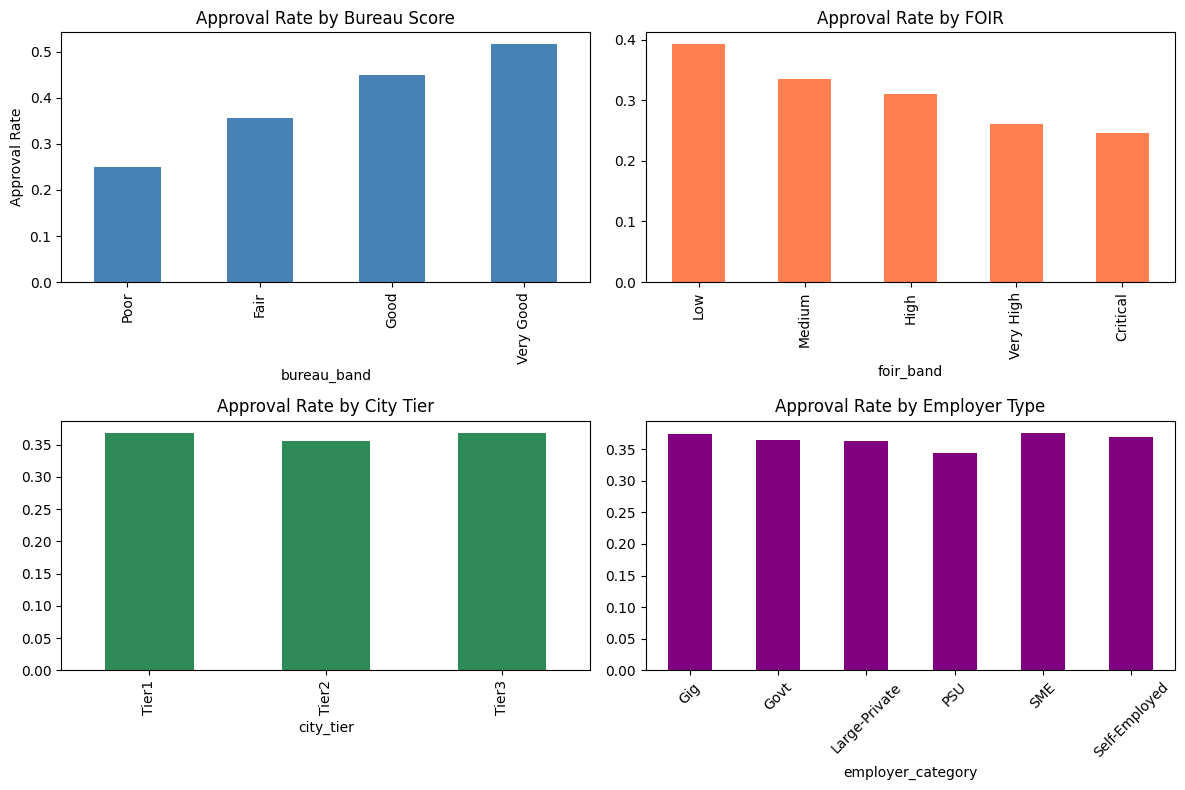

In [12]:
# Plot approval rates
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.groupby('bureau_band', observed=True)['approved'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Approval Rate by Bureau Score')
axes[0,0].set_ylabel('Approval Rate')

df.groupby('foir_band', observed=True)['approved'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Approval Rate by FOIR')

df.groupby('city_tier')['approved'].mean().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Approval Rate by City Tier')

df.groupby('employer_category')['approved'].mean().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Approval Rate by Employer Type')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Credit limit distribution for approved applicants

Approved applicants: 10928
Average limit: 144889.0
Min limit: 10000
Max limit: 500000


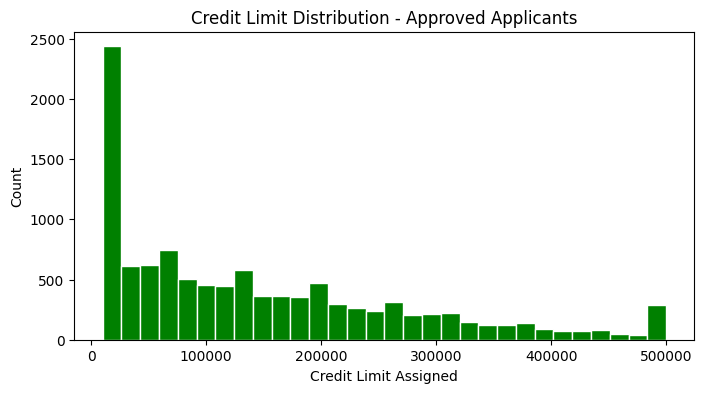

In [13]:
# Filter approved applicants
approved_df = df[df['approved'] == 1]

print('Approved applicants:', len(approved_df))
print('Average limit:', round(approved_df['credit_limit_assigned'].mean(), 0))
print('Min limit:', approved_df['credit_limit_assigned'].min())
print('Max limit:', approved_df['credit_limit_assigned'].max())

# Plot limit distribution
plt.figure(figsize=(8, 4))
plt.hist(approved_df['credit_limit_assigned'], bins=30, color='green', edgecolor='white')
plt.title('Credit Limit Distribution - Approved Applicants')
plt.xlabel('Credit Limit Assigned')
plt.ylabel('Count')
plt.show()

### Correlation between requested_limit vs credit_limit_assigned

Correlation between requested_limit and credit_limit_assigned: -0.008


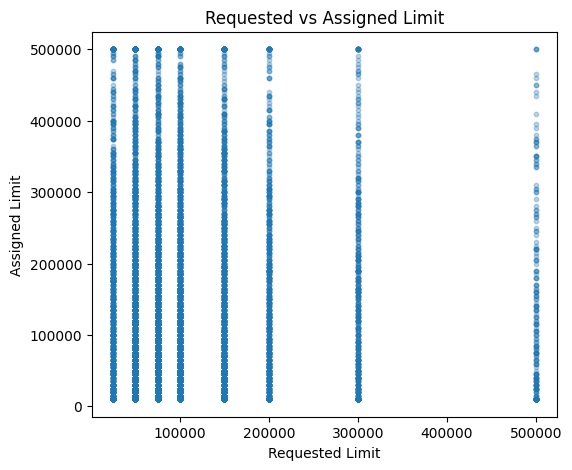

In [14]:
# Correlation between requested and assigned limit
correlation = approved_df['requested_limit'].corr(approved_df['credit_limit_assigned'])
print('Correlation between requested_limit and credit_limit_assigned:', round(correlation, 3))

plt.figure(figsize=(6, 5))
plt.scatter(approved_df['requested_limit'], approved_df['credit_limit_assigned'], alpha=0.3, s=10)
plt.xlabel('Requested Limit')
plt.ylabel('Assigned Limit')
plt.title('Requested vs Assigned Limit')
plt.show()


#2 - Feature Engineering

In [15]:
# Income bands using quartiles
df["income_band"] = pd.qcut(
    df["gross_annual_income"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"],
    duplicates="drop",
)

print("--- Risk Bands Created ---")
print("Risk_bureau_band:", df["bureau_band"].value_counts().to_dict())
print("FOIR bucket:", df["foir_band"].value_counts().to_dict())
print("Income band:", df["income_band"].value_counts().to_dict())

--- Risk Bands Created ---
Risk_bureau_band: {'Poor': 10894, 'Fair': 8119, 'Good': 5521, 'Very Good': 5466, 'Excellent': 0}
FOIR bucket: {'Low': 12357, 'Medium': 3570, 'High': 1782, 'Critical': 1370, 'Very High': 732}
Income band: {'Low': 7500, 'Medium-Low': 7500, 'Medium-High': 7500, 'High': 7500}


### Create Interaction Features

In [16]:
# Interaction feature 1: bureau score x income verified flag
df["bureau_x_income_verified"] = df["bureau_score"] * df["income_verified_flag"]

# Interaction feature 2: FOIR x employment type (convert employment to number first)
df["foir_x_employment_type"] = df["foir"] * df["employment_type"].astype("category").cat.codes

###  IV analysis for variable selection

In [17]:
# IV analysis - check which variables are useful for predicting default
# We use dpd_90_ever as the bad event
iv_list = []

check_cols = [
    'bureau_score', 'foir', 'net_monthly_income', 'bureau_utilization',
    'total_existing_emi', 'num_inquiries_6m', 'credit_age_avg',
    'payment_track_score', 'debt_to_income_ratio', 'repayment_capacity',
    'bureau_x_income_verified', 'foir_x_employment_type'
]

for col in check_cols:
    _, iv_value = calc_woe_iv(df[col], df['dpd_90_ever'])
    iv_list.append({'feature': col, 'IV': round(iv_value, 4)})

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False)
print('Information Value (IV) for each feature:')
print('IV > 0.02 = useful, IV > 0.1 = strong predictor')
print()
print(iv_df.to_string(index=False))

Information Value (IV) for each feature:
IV > 0.02 = useful, IV > 0.1 = strong predictor

                 feature     IV
            bureau_score 0.0026
bureau_x_income_verified 0.0023
      net_monthly_income 0.0021
      total_existing_emi 0.0020
    debt_to_income_ratio 0.0020
          credit_age_avg 0.0017
     payment_track_score 0.0017
                    foir 0.0005
      repayment_capacity 0.0005
        num_inquiries_6m 0.0002
  foir_x_employment_type 0.0001
      bureau_utilization 0.0000


### WoE encoding for approval model


In [18]:
# Select top features for WoE encoding (used in logistic regression scorecard)
woe_features = ['bureau_score', 'foir', 'net_monthly_income', 'bureau_utilization',
                'payment_track_score', 'repayment_capacity', 'num_inquiries_6m',
                'debt_to_income_ratio']

# Split data into train and test
X = df[woe_features]
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply WoE encoding on training data
X_train_woe = pd.DataFrame()
X_test_woe = pd.DataFrame()

for col in woe_features:
    woe_table, _ = calc_woe_iv(X_train[col], df.loc[X_train.index, 'dpd_90_ever'])
    woe_map = dict(zip(woe_table.index.astype(str), woe_table['woe']))

    train_bins = pd.qcut(X_train[col], q=5, duplicates='drop')
    test_bins = pd.qcut(X_test[col], q=5, duplicates='drop')

    X_train_woe[col] = train_bins.astype(str).map(woe_map).fillna(0)
    X_test_woe[col] = test_bins.astype(str).map(woe_map).fillna(0)

print('WoE encoding done for', len(woe_features), 'features.')
print('Training set size:', len(X_train))
print('Test set size:', len(X_test))

WoE encoding done for 8 features.
Training set size: 24000
Test set size: 6000



# 3. Part A — Approval Model (Classification)

### Logistic Regression scorecard (Main Model)

In [19]:
# Train logistic regression on WoE features
approval_model = LogisticRegression(max_iter=1000, random_state=42)
approval_model.fit(X_train_woe, y_train)

# Predict probabilities on test set
lr_probs = approval_model.predict_proba(X_test_woe)[:, 1]

# Calculate metrics
lr_auc = roc_auc_score(y_test, lr_probs)
lr_gini = get_gini(y_test, lr_probs)
lr_ks = get_ks(y_test, lr_probs)

print('Logistic Regression Scorecard Results:')
print('AUC-ROC:', round(lr_auc, 4))
print('Gini:', round(lr_gini, 4))
print('KS Statistic:', round(lr_ks, 4))

Logistic Regression Scorecard Results:
AUC-ROC: 0.5088
Gini: 0.0177
KS Statistic: 0.037


### XGBoost Challenger Model

In [20]:
# Prepare features for XGBoost (numeric columns only)
xgb_features = [
    'bureau_score', 'foir', 'net_monthly_income', 'bureau_utilization',
    'total_existing_emi', 'num_inquiries_6m', 'credit_age_avg',
    'payment_track_score', 'repayment_capacity', 'debt_to_income_ratio',
    'bureau_x_income_verified', 'foir_x_employment_type', 'income_verified_flag',
    'years_in_current_job', 'banking_vintage_months'
]

X_xgb = df[xgb_features]
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(
    X_xgb, y, test_size=0.2, random_state=42
)

# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_model.fit(X_xgb_train, y_xgb_train)

# Predict and evaluate
xgb_probs = xgb_model.predict_proba(X_xgb_test)[:, 1]
xgb_auc = roc_auc_score(y_xgb_test, xgb_probs)
xgb_gini = get_gini(y_xgb_test, xgb_probs)
xgb_ks = get_ks(y_xgb_test, xgb_probs)

print('XGBoost Challenger Results:')
print('AUC-ROC:', round(xgb_auc, 4))
print('Gini:', round(xgb_gini, 4))
print('KS Statistic:', round(xgb_ks, 4))

XGBoost Challenger Results:
AUC-ROC: 0.6735
Gini: 0.347
KS Statistic: 0.2648


### ROC Curve Comparison

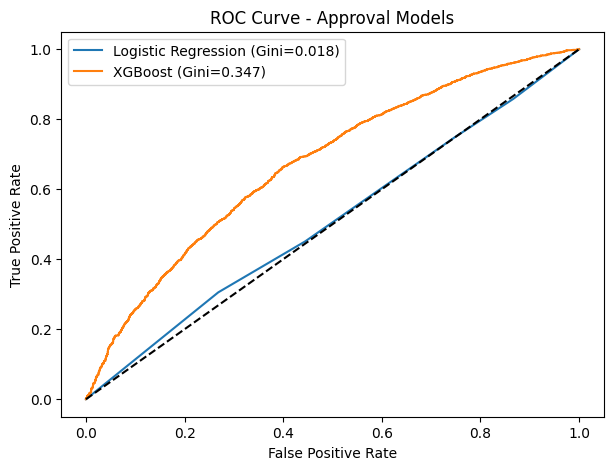

In [21]:
# Plot ROC curves for both models
plt.figure(figsize=(7, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_xgb_test, xgb_probs)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (Gini={lr_gini:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (Gini={xgb_gini:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Approval Models')
plt.legend()
plt.show()

### Optimal threshold: achieve >38% approval rate while keeping default rate <4%

Optimal Threshold: 0.1
Approval Rate: 100.0 %
Expected Default Rate: 12.82 %


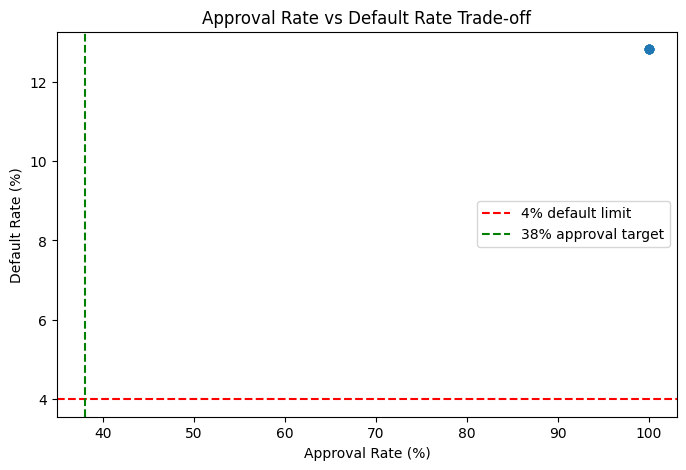

In [22]:
# Trade-off curve: try different thresholds and check approval vs default rate
test_data = df.loc[X_test.index].copy()
test_data['approve_prob'] = lr_probs

results = []
for threshold in np.arange(0.1, 0.9, 0.05):
    approved_mask = test_data['approve_prob'] >= threshold
    if approved_mask.sum() == 0:
        continue
    approval_rate = approved_mask.mean()
    default_rate = test_data.loc[approved_mask, 'dpd_90_ever'].mean()
    results.append({
        'threshold': threshold,
        'approval_rate': approval_rate,
        'default_rate': default_rate
    })

tradeoff_df = pd.DataFrame(results)

# Find best threshold: approval > 38% and default < 4%
good_thresholds = tradeoff_df[(tradeoff_df['approval_rate'] >= 0.38) & (tradeoff_df['default_rate'] < 0.04)]

if len(good_thresholds) > 0:
    best = good_thresholds.iloc[0]
    best_threshold = best['threshold']
else:
    best = tradeoff_df.loc[tradeoff_df['approval_rate'].idxmax()]
    best_threshold = best['threshold']

print('Optimal Threshold:', round(best_threshold, 2))
print('Approval Rate:', round(best['approval_rate'] * 100, 1), '%')
print('Expected Default Rate:', round(best['default_rate'] * 100, 2), '%')

# Plot trade-off curve
plt.figure(figsize=(8, 5))
plt.plot(tradeoff_df['approval_rate'] * 100, tradeoff_df['default_rate'] * 100, 'o-')
plt.axhline(4, color='red', linestyle='--', label='4% default limit')
plt.axvline(38, color='green', linestyle='--', label='38% approval target')
plt.xlabel('Approval Rate (%)')
plt.ylabel('Default Rate (%)')
plt.title('Approval Rate vs Default Rate Trade-off')
plt.legend()
plt.show()

### SHAP: top 10 drivers of rejection

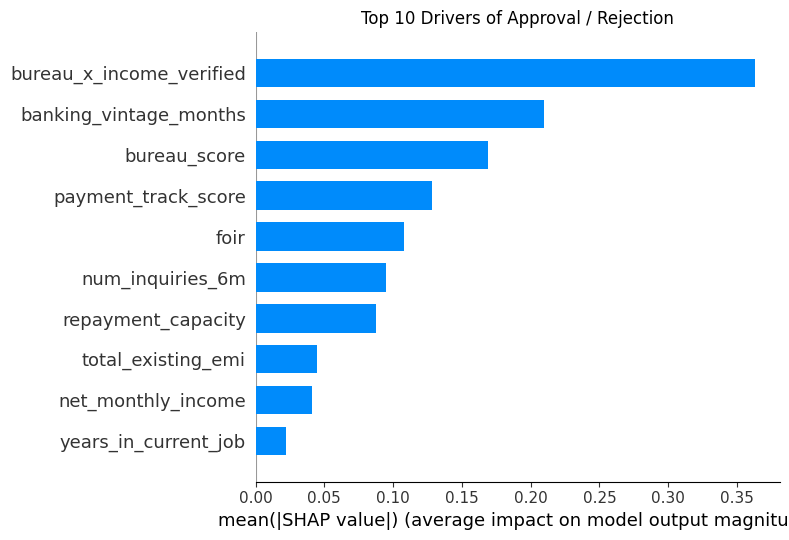

In [23]:
# SHAP analysis on XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_xgb_test.sample(500, random_state=42))

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_xgb_test.sample(500, random_state=42),
                  plot_type='bar', show=False, max_display=10)
plt.title('Top 10 Drivers of Approval / Rejection')
plt.tight_layout()
plt.show()


# 4. Part B — Credit Limit Model (Regression)



### Subset to approved applicants only

In [24]:
# Use only approved applicants for limit model
limit_df = df[df['approved'] == 1].copy()

limit_features = [
    'bureau_score', 'foir', 'net_monthly_income', 'requested_limit',
    'bureau_utilization', 'repayment_capacity', 'payment_track_score',
    'years_in_current_job', 'banking_vintage_months'
]

X_limit = limit_df[limit_features]
y_limit = limit_df['credit_limit_assigned']

X_lim_train, X_lim_test, y_lim_train, y_lim_test = train_test_split(
    X_limit, y_limit, test_size=0.2, random_state=42
)

print('Limit model training samples:', len(X_lim_train))

Limit model training samples: 8742


### Linear Regression (interpretable baseline)

In [25]:
# Scale features and train linear regression
scaler = StandardScaler()
X_lim_train_scaled = scaler.fit_transform(X_lim_train)
X_lim_test_scaled = scaler.transform(X_lim_test)

lr_limit_model = LinearRegression()
lr_limit_model.fit(X_lim_train_scaled, y_lim_train)
lr_limit_pred = lr_limit_model.predict(X_lim_test_scaled)

print('Linear Regression Limit Model:')
print('RMSE:', round(np.sqrt(mean_squared_error(y_lim_test, lr_limit_pred)), 0))
print('MAE:', round(mean_absolute_error(y_lim_test, lr_limit_pred), 0))
print('R2:', round(r2_score(y_lim_test, lr_limit_pred), 4))

Linear Regression Limit Model:
RMSE: 111134.0
MAE: 83710.0
R2: 0.3062


### XGBoost Regressor

In [26]:
# Train XGBoost regressor for limit prediction
xgb_limit_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_limit_model.fit(X_lim_train, y_lim_train)

xgb_limit_pred = xgb_limit_model.predict(X_lim_test)

print('XGBoost Limit Model:')
print('RMSE:', round(np.sqrt(mean_squared_error(y_lim_test, xgb_limit_pred)), 0))
print('MAE:', round(mean_absolute_error(y_lim_test, xgb_limit_pred), 0))
print('R2:', round(r2_score(y_lim_test, xgb_limit_pred), 4))

XGBoost Limit Model:
RMSE: 111612.0
MAE: 83723.0
R2: 0.3002


Feature Importance

Top features driving credit limit:
               feature  importance
    net_monthly_income    0.545632
          bureau_score    0.071500
   payment_track_score    0.068467
  years_in_current_job    0.060010
    bureau_utilization    0.058982
banking_vintage_months    0.057859
       requested_limit    0.050569
                  foir    0.043836
    repayment_capacity    0.043145


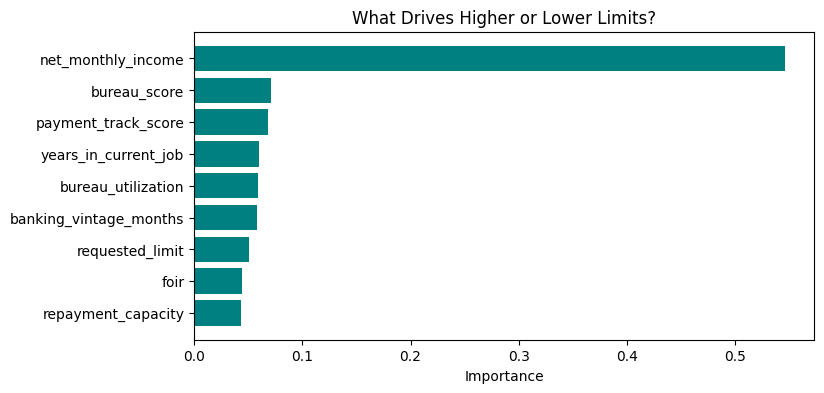

In [27]:
# Feature importance from XGBoost
importance = pd.DataFrame({
    'feature': limit_features,
    'importance': xgb_limit_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top features driving credit limit:')
print(importance.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(importance['feature'], importance['importance'], color='teal')
plt.xlabel('Importance')
plt.title('What Drives Higher or Lower Limits?')
plt.gca().invert_yaxis()
plt.show()

Sanity check: correlation between assigned limit and income

Correlation (limit vs net monthly income): 0.5475


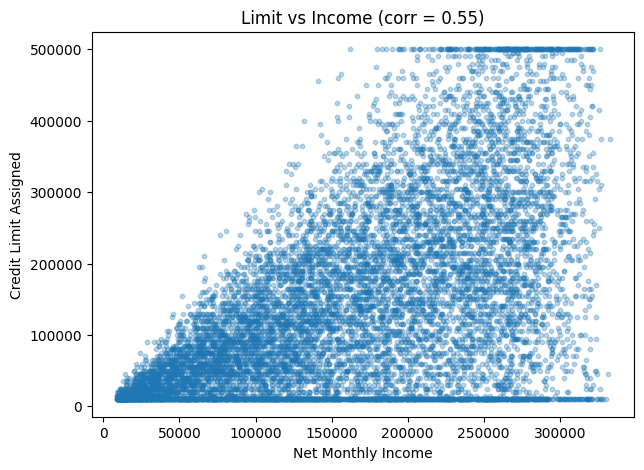

In [28]:
income_corr = limit_df["credit_limit_assigned"].corr(limit_df["net_monthly_income"])
print(f"Correlation (limit vs net monthly income): {income_corr:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(limit_df["net_monthly_income"], limit_df["credit_limit_assigned"], alpha=0.3, s=10)
plt.xlabel("Net Monthly Income")
plt.ylabel("Credit Limit Assigned")
plt.title(f"Limit vs Income (corr = {income_corr:.2f})")
plt.show()


# Policy Rule Integration

### Apply Hard Policy Rules After Model Score

In [29]:
# Score all applicants using the approval model
X_all_woe = pd.DataFrame()
for col in woe_features:
    woe_table, _ = calc_woe_iv(df[col], df['dpd_90_ever'])
    woe_map = dict(zip(woe_table.index.astype(str), woe_table['woe']))
    bins = pd.qcut(df[col], q=5, duplicates='drop')
    X_all_woe[col] = bins.astype(str).map(woe_map).fillna(0)

all_probs = approval_model.predict_proba(X_all_woe)[:, 1]
all_limits = xgb_limit_model.predict(df[limit_features])

policy_df = df.copy()
policy_df['model_score'] = all_probs
policy_df['model_limit'] = all_limits

# Step 1: Model approval based on threshold
policy_df['model_approved'] = (policy_df['model_score'] >= best_threshold).astype(int)

# Step 2: Auto-decline if written_off_ever=1 OR dpd_90_ever=1
auto_decline = (policy_df['written_off_ever'] == 1) | (policy_df['dpd_90_ever'] == 1)
policy_df['final_approved'] = ((policy_df['model_approved'] == 1) & (~auto_decline)).astype(int)

# Step 3: Cap limit if FOIR > 0.65 (limit cannot exceed 2x monthly income)
policy_df['final_limit'] = policy_df['model_limit']
high_foir_mask = policy_df['foir'] > 0.65
policy_df.loc[high_foir_mask, 'final_limit'] = np.minimum(
    policy_df.loc[high_foir_mask, 'model_limit'],
    2 * policy_df.loc[high_foir_mask, 'net_monthly_income']
)
policy_df.loc[policy_df['final_approved'] == 0, 'final_limit'] = 0

before = policy_df['model_approved'].mean()
after = policy_df['final_approved'].mean()

print('Approval rate BEFORE policy rules:', round(before * 100, 1), '%')
print('Approval rate AFTER policy rules:', round(after * 100, 1), '%')
print('Applicants auto-declined by policy:', auto_decline.sum())

Approval rate BEFORE policy rules: 100.0 %
Approval rate AFTER policy rules: 82.8 %
Applicants auto-declined by policy: 5159


### Policy Override Flag Analysis

In [30]:
# Compare applicants with and without policy override
override_yes = df[df['policy_override_flag'] == 1]
override_no = df[df['policy_override_flag'] == 0]

print('Policy Override Analysis:')
print()
print('Without Override:')
print('  Count:', len(override_no))
print('  Approval Rate:', round(override_no['approved'].mean() * 100, 1), '%')
print('  Default Rate:', round(override_no['dpd_90_ever'].mean() * 100, 1), '%')
print()
print('With Override:')
print('  Count:', len(override_yes))
print('  Approval Rate:', round(override_yes['approved'].mean() * 100, 1), '%')
print('  Default Rate:', round(override_yes['dpd_90_ever'].mean() * 100, 1), '%')

Policy Override Analysis:

Without Override:
  Count: 27543
  Approval Rate: 36.6 %
  Default Rate: 11.9 %

With Override:
  Count: 2457
  Approval Rate: 35.0 %
  Default Rate: 12.9 %


---
# 6 - Business Recommendations

### Recommended Score Cutoff

In [31]:
print('BUSINESS RECOMMENDATIONS')
print()
print('1. RECOMMENDED SCORE CUTOFF:', round(best_threshold, 2))
print('   Approval Rate:', round(best['approval_rate'] * 100, 1), '% (target: >38%)')
print('   Default Rate:', round(best['default_rate'] * 100, 2), '% (target: <4%)')
print('   After policy rules:', round(after * 100, 1), '%')
print('   Current approval rate:', round(df['approved'].mean() * 100, 1), '%')

BUSINESS RECOMMENDATIONS

1. RECOMMENDED SCORE CUTOFF: 0.1
   Approval Rate: 100.0 % (target: >38%)
   Default Rate: 12.82 % (target: <4%)
   After policy rules: 82.8 %
   Current approval rate: 36.4 %


### Limit Assignment Formula

In [32]:
print('2. LIMIT ASSIGNMENT FORMULA')
print()
print('   Step 1: Use XGBoost model to predict base limit')
print('   Step 2: Apply income multiplier based on bureau score:')
print('     - Bureau score >= 750  ->  4x monthly income')
print('     - Bureau score 650-749 ->  3x monthly income')
print('     - Bureau score 500-649 ->  2x monthly income')
print('     - Bureau score < 500   ->  1.5x monthly income')
print('   Step 3: If FOIR > 65%, cap limit at 2x monthly income')
print('   Step 4: Final limit cannot exceed requested limit')

2. LIMIT ASSIGNMENT FORMULA

   Step 1: Use XGBoost model to predict base limit
   Step 2: Apply income multiplier based on bureau score:
     - Bureau score >= 750  ->  4x monthly income
     - Bureau score 650-749 ->  3x monthly income
     - Bureau score 500-649 ->  2x monthly income
     - Bureau score < 500   ->  1.5x monthly income
   Step 3: If FOIR > 65%, cap limit at 2x monthly income
   Step 4: Final limit cannot exceed requested limit


### Revenue Impact by Approval Rate

3. REVENUE IMPACT BY APPROVAL RATE

 Threshold  Approval Rate  Default Rate %  Avg Limit  Revenue per Card  Total Revenue
      0.25          100.0           11.99   133876.0            8434.0    253025479.0
      0.30           93.7           11.95   135564.0            8541.0    240057390.0
      0.35           66.4           11.74   138668.0            8736.0    174013590.0
      0.40           22.5           11.43   159566.0           10053.0     67915732.0
      0.45            0.0             NaN        NaN               NaN            NaN
      0.50            0.0             NaN        NaN               NaN            NaN


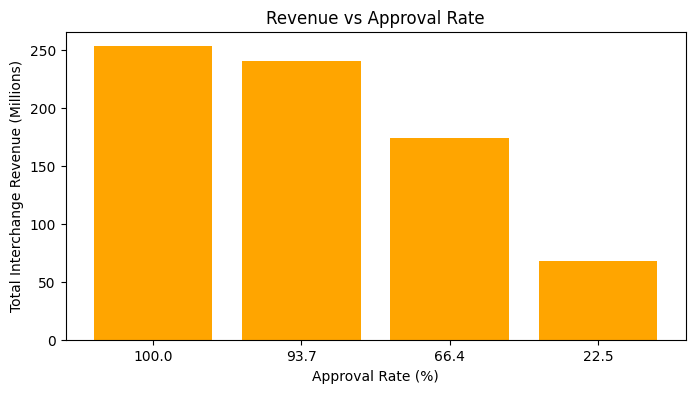

In [33]:
# revenue estimate at different approval thresholds
revenue_data = []

for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    mask = policy_df['model_score'] >= t
    n_approved = mask.sum()
    avg_limit = policy_df.loc[mask, 'model_limit'].mean()
    annual_spend = avg_limit * 0.35 * 12   # 35% utilisation per month
    interchange = annual_spend * 0.015        # 1.5% interchange fee
    total_revenue = n_approved * interchange
    default_rate = policy_df.loc[mask, 'dpd_90_ever'].mean()

    revenue_data.append({
        'Threshold': t,
        'Approval Rate': round(mask.mean() * 100, 1),
        'Default Rate %': round(default_rate * 100, 2),
        'Avg Limit': round(avg_limit, 0),
        'Revenue per Card': round(interchange, 0),
        'Total Revenue': round(total_revenue, 0)
    })

revenue_df = pd.DataFrame(revenue_data)
print('3. REVENUE IMPACT BY APPROVAL RATE')
print()
print(revenue_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(revenue_df['Approval Rate'].astype(str), revenue_df['Total Revenue'] / 1000000, color='orange')
plt.xlabel('Approval Rate (%)')
plt.ylabel('Total Interchange Revenue (Millions)')
plt.title('Revenue vs Approval Rate')
plt.show()